In [7]:
import os
import time
import argparse
import sys
from pathlib import Path
from copy import deepcopy
import gymnasium as gym
import numpy as np
import yaml
import jax
import torch
import f1tenth_gym
from f1tenth_gym.envs import F110Env
from f1tenth_planning.control.config.controller_config import dynamic_ap_mppi_config
from f1tenth_planning.control.config.dynamics_config import f1tenth_params
from f1tenth_planning.control.dynamics_models.dynamic_model import DynamicBicycleModel

from dpc.constraints import *
from dpc.discretizers import rk4_discretization_torch
from dpc.policy import NeuralDistributionPolicy, PolicyBounds
from DMPPI_config import create_DMPPI_config
from DMPPI_solver import DMPPI_Solver
from trainer.DMPPI_trainer import DMPPI_Trainer


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
if device.type == "cuda":
    torch.cuda.manual_seed_all(0)

# Load config
with open("dmppi_config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# create environment
env: F110Env = gym.make(
    "f1tenth_gym:f1tenth-v0",
    config={
        "map": cfg["map"],
        "num_agents": 1,
        "control_input": ["accl", "steering_speed"],
        "observation_config": {"type": "dynamic_state"},
        "params": F110Env.f1tenth_vehicle_params(),
    },
    render_mode=None,
)

# Load track waypoints
waypoints_track = env.unwrapped.track
# Get vehicle parameters
params = f1tenth_params()

# Build state constraints from vehicle parameters
# x = [x, y, delta, v, yaw, yaw_rate, beta]
x_min_constrained = np.array([
    -np.inf,           # x position: unconstrained
    -np.inf,           # y position: unconstrained  
    params.MIN_STEER,  # steering angle
    params.MIN_SPEED,  # velocity
    -np.inf,           # yaw: unconstrained
    -np.inf,           # yaw_rate: unconstrained
    -np.inf,           # beta: unconstrained
])
x_max_constrained = np.array([
    np.inf,            # x position: unconstrained
    np.inf,            # y position: unconstrained
    params.MAX_STEER,  # steering angle
    params.MAX_SPEED,  # for testing, set max speed to 5 m/s
    np.inf,            # yaw: unconstrained
    np.inf,            # yaw_rate: unconstrained
    np.inf,            # beta: unconstrained
])

# TODO: Include safety constraints
constraints = [
    make_state_min_constraint_batched(x_min_constrained),
    make_state_max_constraint_batched(x_max_constrained),
]    
tp = dict(cfg.get("train_params", {}))

# Add constraints and lambdas to config
config = create_DMPPI_config(cfg=cfg)
config.constraints = constraints
lam = float(tp.get("constraint_weight", 1e2))
config.lambdas = [lam] * len(constraints) # penalty weights for constraints
config.alpha = float(tp.get("exploration_weight", 1e0)) # weight for exploration

print(
    "\033[31;42m"
    "[dmppi config] "
    f"Constraint penalty weight: {lam}, "
    f"Exploration weight: {config.alpha}"
    "\033[0m"
)
print("-"*50)

# Initialize the neural control policy
bounds = PolicyBounds(
    delta_v_min=params.MIN_DSTEER,
    delta_v_max=params.MAX_DSTEER,
    a_min=params.MIN_ACCEL,
    a_max=params.MAX_ACCEL,
)
policy = NeuralDistributionPolicy(
    in_dim=10, # 7 state + 3 ref
    hidden_dim=64,
    num_hidden_layers=5,
    bounds=bounds,
    activation="gelu",
    dropout=0.0,
)

# Initialize the dynamic model
model = DynamicBicycleModel(params)

# Initialize the DPC solver
solver = DMPPI_Solver(
    config=config,
    model=model,
    policy=policy,
    discretizer=rk4_discretization_torch,
    device = device
)

waypoints = np.vstack(
    [
        waypoints_track.raceline.xs,  # x
        waypoints_track.raceline.ys,  # y
        np.zeros_like(waypoints_track.raceline.xs), # steering angle reference
        waypoints_track.raceline.vxs,  # v
        waypoints_track.raceline.yaws,  # yaw
        np.zeros_like(waypoints_track.raceline.xs), # yaw rate reference
        np.zeros_like(waypoints_track.raceline.xs), # slip angle
    ]).T

pose_ref = np.vstack(
    [
        waypoints_track.raceline.xs, # x
        waypoints_track.raceline.ys, # y
        waypoints_track.raceline.yaws, # yaw
    ]).T

trainer = DMPPI_Trainer(solver=solver, device=device)
training_params = {
    "n_samples": int(tp.get("n_samples", 1e6)),
    "num_epochs": int(tp.get("num_epochs", 50)),
    "steps_per_epoch": int(tp.get("steps_per_epoch", 200)),
    "batch_size": int(tp.get("batch_size", 64)),
    "n_loss_rollouts": int(tp.get("n_loss_rollouts", 2)),
    "lr": float(tp.get("lr", 1e-3)),
    "weight_decay": float(tp.get("weight_decay", 0.0)),
    "grad_clip": float(tp.get("grad_clip", 1.0)),
    "log_every": int(tp.get("log_every", 20)),
    "save_path": tp.get("save_path", "dpc_policy.pt"),
    "save_every": int(tp.get("save_every", 10)),
    "plateau_factor": float(tp.get("plateau_factor", 0.5)),
    "plateau_patience": int(tp.get("plateau_patience", 5)),
    "plateau_min_lr": float(tp.get("plateau_min_lr", 1e-6)),
    "plateau_threshold": float(tp.get("plateau_threshold", 1e-4)),
    "plateau_cooldown": int(tp.get("plateau_cooldown", 0)),
    "eval_batch_size": int(tp.get("eval_batch_size", 256)),
    "early_stop_patience": int(tp.get("early_stop_patience", 10)),
    "early_stop_min_delta": float(tp.get("early_stop_min_delta", 1e-4)),
    "penalty_increase_factor": float(tp.get("penalty_increase_factor", 1.5)),
}

trainer.generate_samples(
    pose_ref=torch.from_numpy(pose_ref),
    N=config.N, sample_size=training_params["n_samples"], 
    device=device)

[dmppi config] Constraint penalty weight: 100.0, Exploration weight: 1.0
--------------------------------------------------


In [9]:
import matplotlib.pyplot as plt
pose = trainer.samples["R"][:1000, :, :].detach().cpu().numpy()
x0 = trainer.samples["x0"][:1000, :].detach().cpu().numpy()


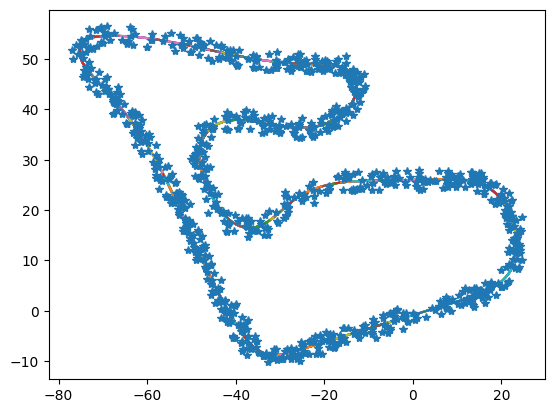

In [10]:
# plt.plot(pose[:,:,2])
plt.plot(pose[:,:,0].T, pose[:,:,1].T)
plt.plot(x0[:,0], x0[:,1], "*")
plt.show()

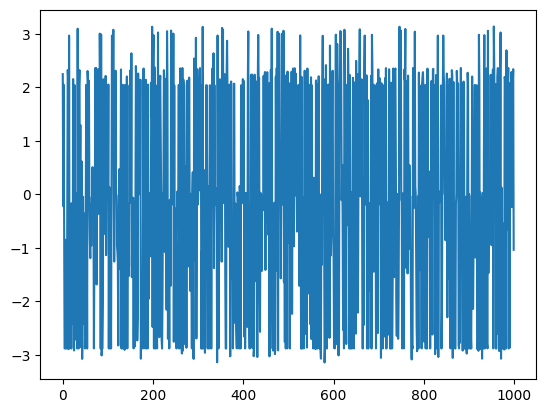

In [11]:
plt.plot(pose[:,0,2])

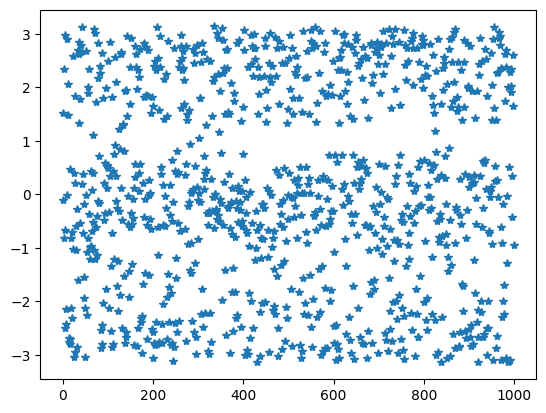

In [12]:
plt.plot(x0[:,4], "*")


TypeError: tuple indices must be integers or slices, not tuple